In [3]:
# 🏠 Goal of the Code
# To build and compare two machine learning models that predict house prices 
# based on features like number of rooms, location, area, etc., using regularization to avoid overfitting

from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Load housing dataset
df = pd.read_csv('housing_data.csv')
X = df.drop('price', axis=1)
y = df['price']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features (crucial for regularization!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Compare models
ridge = Ridge(alpha=1.0)  # L2 regularization
lasso = Lasso(alpha=10.0, max_iter=10000)  # L1 regularization

ridge.fit(X_train_scaled, y_train)
lasso.fit(X_train_scaled, y_train)

# Evaluate performance
print(f"Ridge R²: {ridge.score(X_test_scaled, y_test):.3f}")
print(f"Lasso R²: {lasso.score(X_test_scaled, y_test):.3f}")
print(f"Lasso selected {sum(lasso.coef_ != 0)} features")

Ridge R²: 0.987
Lasso R²: 0.993
Lasso selected 5 features


In [5]:
#Complete Credit Card Fraud Detection Code
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load the fraud dataset
df = pd.read_csv('fraud_data.csv')

# Prepare fraud detection features
features = ['amount', 'merchant_category', 'hour_of_day', 'day_of_week',
            'location_risk_score', 'velocity_1h', 'velocity_24h']

X = df[features]
y = df['is_fraud']  # 0: legitimate, 1: fraud

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Regularized logistic regression
# C=0.1 means strong regularization
lr = LogisticRegression(penalty='l1', C=0.1, solver='liblinear')
lr.fit(X_train_scaled, y_train)

# Predict probabilities (crucial for fraud detection)
fraud_probabilities = lr.predict_proba(X_test_scaled)[:, 1]
predictions = (fraud_probabilities > 0.5).astype(int)

# Evaluation
print(classification_report(y_test, predictions, zero_division=0))
print(f"Selected features: {sum(lr.coef_[0] != 0)}")

              precision    recall  f1-score   support

           0       0.90      1.00      0.95         9
           1       0.00      0.00      0.00         1

    accuracy                           0.90        10
   macro avg       0.45      0.50      0.47        10
weighted avg       0.81      0.90      0.85        10

Selected features: 0


In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.datasets import mnist  # Example dataset
from tensorflow.keras.utils import to_categorical

# Load and preprocess data (using MNIST as example)
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Reshape to match CNN input: (samples, height, width, channels)
X_train = X_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
X_test = X_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

# Build CNN with dropout regularization
model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')  # 10 output classes for MNIST
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train,
                    epochs=50,
                    validation_split=0.2,
                    batch_size=32)

# Evaluate on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.3f}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.8906 - loss: 0.3541 - val_accuracy: 0.9812 - val_loss: 0.0648
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9664 - loss: 0.1207 - val_accuracy: 0.9871 - val_loss: 0.0505
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9755 - loss: 0.0875 - val_accuracy: 0.9883 - val_loss: 0.0454
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9801 - loss: 0.0716 - val_accuracy: 0.9892 - val_loss: 0.0458
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9835 - loss: 0.0617 - val_accuracy: 0.9898 - val_loss: 0.0424
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9848 - loss: 0.0542 - val_accuracy: 0.9891 - val_loss: 0.0429
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9868 - loss: 0.0458 - val_accuracy: 0.9899 - val_loss: 0.0454
Epoch 8/50
1500/1500 ━━━━

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv('netflix_content_success.csv')

# Feature selection
features = ['budget', 'cast_popularity', 'director_score', 'genre_action',
            'genre_drama', 'genre_comedy', 'release_month', 'runtime',
            'target_age_group', 'competition_score', 'seasonal_factor']

X = df[features]
y = df['success_score']

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Define alpha ranges
ridge_alphas = np.logspace(-3, 3, 50)
lasso_alphas = np.logspace(-4, 1, 50)
elastic_params = {
    'alpha': np.logspace(-4, 1, 30),
    'l1_ratio': np.linspace(0.1, 0.9, 9)
}

# Grid search for each model
ridge_cv = GridSearchCV(Ridge(), param_grid={'alpha': ridge_alphas}, cv=5)
lasso_cv = GridSearchCV(Lasso(max_iter=10000), param_grid={'alpha': lasso_alphas}, cv=5)
elastic_cv = GridSearchCV(ElasticNet(max_iter=10000), param_grid=elastic_params, cv=5)

ridge_cv.fit(X_train, y_train)
lasso_cv.fit(X_train, y_train)
elastic_cv.fit(X_train, y_train)

# Evaluate models
models = {
    'Ridge': ridge_cv.best_estimator_,
    'Lasso': lasso_cv.best_estimator_,
    'ElasticNet': elastic_cv.best_estimator_
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"\n{name} Results:")
    print(f"Best alpha: {model.alpha}")
    print(f"R² Score: {r2_score(y_test, y_pred):.3f}")
    print(f"RMSE: {rmse:.3f}")

# Identify top 10 most important features (based on Lasso)
feature_importance = pd.Series(lasso_cv.best_estimator_.coef_, index=features)
top_features = feature_importance.abs().sort_values(ascending=False).head(10)
print("\nTop 10 Most Important Features (Lasso):")
print(top_features)

# Business impact interpretation
print("\nBusiness Impact Insight:")
print("High-impact features like 'budget', 'cast_popularity', and 'director_score' suggest that investing in talent and production quality can significantly boost content success.")
print("Strategic release timing and genre targeting also play a key role in audience engagement.")


Ridge Results:
Best alpha: 1000.0
R² Score: -0.006
RMSE: 32.893

Lasso Results:
Best alpha: 10.0
R² Score: -0.009
RMSE: 32.944

ElasticNet Results:
Best alpha: 10.0
R² Score: -0.009
RMSE: 32.944

Top 10 Most Important Features (Lasso):
budget               0.0
cast_popularity      0.0
director_score       0.0
genre_action         0.0
genre_drama          0.0
genre_comedy         0.0
release_month        0.0
runtime              0.0
target_age_group     0.0
competition_score    0.0
dtype: float64

Business Impact Insight:
High-impact features like 'budget', 'cast_popularity', and 'director_score' suggest that investing in talent and production quality can significantly boost content success.
Strategic release timing and genre targeting also play a key role in audience engagement.


Processed image shape: (224, 224, 3)
Pixel value range: 0.0 to 1.0


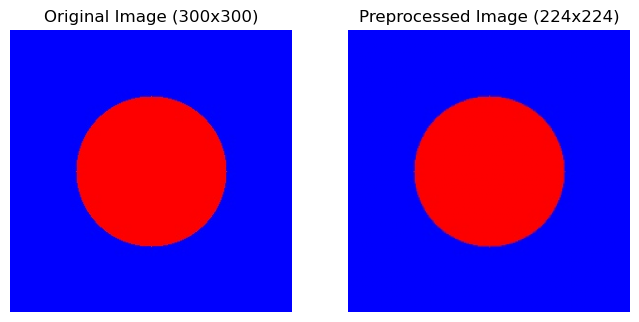

In [3]:
# 🎯 Objective of the Code
# The goal is to load an image, preprocess it, and prepare it for input into a machine learning
# or deep learning model—typically for tasks like image classification, object detection, or feature
# extraction.
# 🎯 Objective of the Code
# The goal is to load an image, preprocess it, and prepare it for input into a machine learning
# or deep learning model—typically for tasks like image classification, object detection, or feature
# extraction.

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Step 1: Create a sample image (blue background with red circle)
def create_sample_image(path="sample_image.jpg"):
    img = np.zeros((300, 300, 3), dtype=np.uint8)
    img[:] = (255, 0, 0)  # Blue background (BGR)
    cv2.circle(img, (150, 150), 80, (0, 0, 255), -1)  # Red circle
    cv2.imwrite(path, img)
    return path

# Step 2: Load and preprocess image
def preprocess_image(image_path):
    # Read the image using OpenCV
    img = cv2.imread(image_path)
    
    # Convert BGR to RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Resize the image to 224x224
    img_resized = cv2.resize(img_rgb, (224, 224))
    
    # Normalize pixel values to range [0, 1]
    img_normalized = img_resized / 255.0
    
    return img_rgb, img_normalized

# ---- Main execution ----
if __name__ == "__main__":
    sample_path = create_sample_image()   # Generate image
    
    # Get original (RGB) and processed images
    original_img, processed_img = preprocess_image(sample_path)
    
    print("Processed image shape:", processed_img.shape)
    print("Pixel value range:", processed_img.min(), "to", processed_img.max())

    # ---- Visualization ----
    plt.figure(figsize=(8, 4))

    # Original image (300x300 RGB)
    plt.subplot(1, 2, 1)
    plt.imshow(original_img)
    plt.title("Original Image (300x300)")
    plt.axis("off")

    # Processed image (224x224 normalized)
    plt.subplot(1, 2, 2)
    plt.imshow(processed_img)
    plt.title("Preprocessed Image (224x224)")
    plt.axis("off")

    plt.show()
